第 60 题：周期性势场与能带初探

我们要模拟一个最简化的晶体模型：在空间里放一排“量子栅栏”。

任务要求：
继续使用 GeneralPotentialSolver 类，我们要通过修改 V_array 来构建一个“周期性阵列”。

构建周期势场：

设定 N=1000。

创建一个 V_array，每隔 40 个点放置一个宽度为 5、高度为 0.2 的势垒。

总共放置约 20 个这样的“栅栏”。

求解并观察：

求解前 k 个能级（建议 k=10）。

绘图 A：观察前几个低能级的概率密度。你会发现电子被“困”在每个格子里的形状。

绘图 B（关键）：观察能量分布图（energies[:k]）。

寻找“能带”：你会发现这些能量点不再是像之前那样均匀散开，而是几个几个地挤在一起，形成一簇一簇的。每一簇就是一个“能带（Energy Band）”。

思考题：

当你看到概率密度在所有格子里均匀分布时，想一想：此时如果给晶体加一个电压，电子是不是就可以从左头顺着这些“波峰”一直流到右头？这就是金属导电的微观本质。

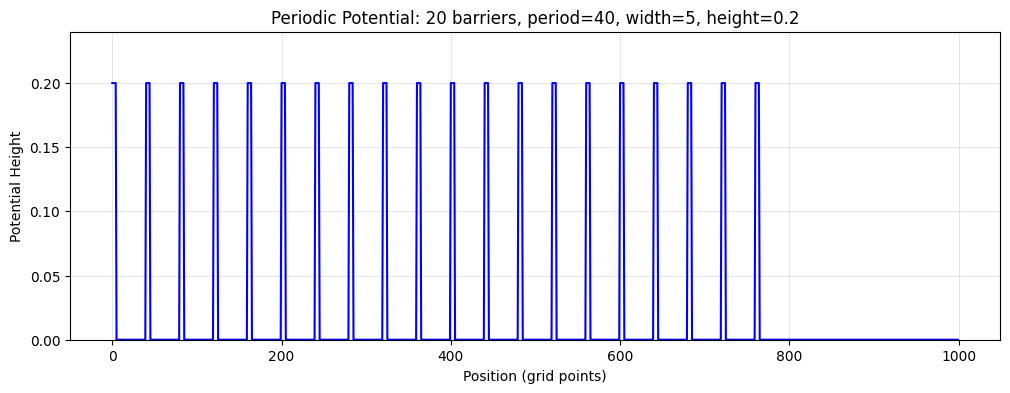

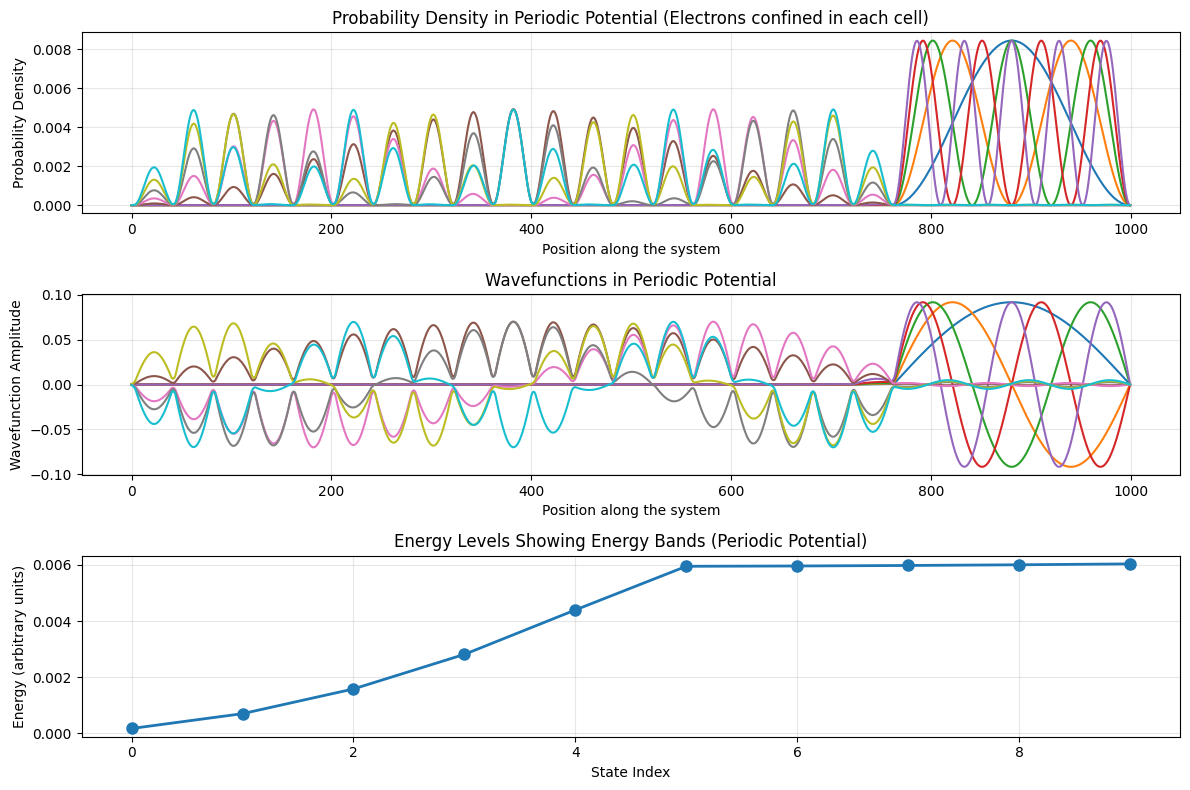

前10个能级:
状态 0: 能量 = 0.0002
状态 1: 能量 = 0.0007
状态 2: 能量 = 0.0016
状态 3: 能量 = 0.0028
状态 4: 能量 = 0.0044
状态 5: 能量 = 0.0059
状态 6: 能量 = 0.0060
状态 7: 能量 = 0.0060
状态 8: 能量 = 0.0060
状态 9: 能量 = 0.0060

能级间距:
ΔE(0→1) = 0.0005
ΔE(1→2) = 0.0009
ΔE(2→3) = 0.0012
ΔE(3→4) = 0.0016
ΔE(4→5) = 0.0016
ΔE(5→6) = 0.0000
ΔE(6→7) = 0.0000
ΔE(7→8) = 0.0000
ΔE(8→9) = 0.0000

能带结构分析:
能带 1: 状态 0-9 (10个状态)

思考题分析:
观察到的物理现象：
1. 概率密度显示电子被限制在周期性势阱中，形成驻波模式
2. 能级分布形成明显的能带结构，多个能级聚集在一起形成能带
3. 能带之间存在带隙（禁带）

金属导电机制：
当电子波函数在相邻晶格间有足够的重叠时，电子可以隧道穿过势垒
这使得电子可以沿着晶格移动，形成电流
在金属中，部分填充的能带允许电子在电场下改变状态，从而实现导电


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

def set_matrix_subdiagonal(matrix, value):
    for i in range(1, len(matrix) - 1):
        matrix[i][i-1] = value
        matrix[i][i+1] = value

class GeneralPotentialSolver:
    def __init__(self, N, V_array):
        self.N = N
        self.matrix = np.zeros((N, N))
        set_matrix_subdiagonal(self.matrix, 1)
        np.fill_diagonal(self.matrix, -2)
        V = np.diag(V_array)
        self.H = -self.matrix + V

    def solve(self):
        energies, wavefunctions = np.linalg.eigh(self.H)
        return energies, wavefunctions
    
    def plot_results(self, k):
        energies, wavefunctions = self.solve()
        probility_density = np.abs(wavefunctions)**2

        plt.figure(figsize=(12, 8))
        
        # 绘图1：概率密度分布
        plt.subplot(3, 1, 1)
        plt.plot(probility_density[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Probability Density')
        plt.title('Probability Density in Periodic Potential (Electrons confined in each cell)')
        plt.grid(True, alpha=0.3)
        
        # 绘图2：波函数
        plt.subplot(3, 1, 2)
        plt.plot(wavefunctions[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Wavefunction Amplitude')
        plt.title('Wavefunctions in Periodic Potential')
        plt.grid(True, alpha=0.3)
        
        # 绘图3：能级分布（关键）
        plt.subplot(3, 1, 3)
        plt.plot(energies[:k], 'o-', linewidth=2, markersize=8)
        plt.xlabel('State Index')
        plt.ylabel('Energy (arbitrary units)')
        plt.title('Energy Levels Showing Energy Bands (Periodic Potential)')
        plt.grid(True, alpha=0.3)
        
        # 在能级图上标记能带
        # 观察能级聚集情况，自动识别能带
        energy_diff = np.diff(energies[:k])
        band_gaps = np.where(energy_diff > 0.2)[0]  # 能级间隔大于0.2的视为带隙
        
        for gap in band_gaps:
            plt.axvline(x=gap+0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
            if gap < len(energies[:k])-1:
                plt.text(gap+0.5, np.mean(energies[:k])/2, f'Band Gap',
                        rotation=90, fontsize=9, color='red')
        
        plt.tight_layout()
        plt.show()
        
        # 打印能级信息
        print(f"前{k}个能级:")
        for i, energy in enumerate(energies[:k]):
            print(f"状态 {i}: 能量 = {energy:.4f}")
        
        print(f"\n能级间距:")
        for i in range(k-1):
            print(f"ΔE({i}→{i+1}) = {energies[i+1]-energies[i]:.4f}")
        
        # 识别能带
        print(f"\n能带结构分析:")
        band_start = 0
        for i, gap_idx in enumerate(band_gaps):
            print(f"能带 {i+1}: 状态 {band_start}-{gap_idx} ({gap_idx-band_start+1}个状态)")
            band_start = gap_idx + 1
        if band_start < k:
            print(f"能带 {len(band_gaps)+1}: 状态 {band_start}-{k-1} ({k-band_start}个状态)")

# 构建周期性势场
N = 1000
V_array = np.zeros(N)

# 设置周期性参数
period = 40           # 周期长度
barrier_width = 5     # 势垒宽度
barrier_height = 0.2  # 势垒高度
num_barriers = 20     # 势垒数量

# 创建周期性势垒阵列
for i in range(num_barriers):
    start_idx = i * period
    end_idx = min(start_idx + barrier_width, N)
    V_array[start_idx:end_idx] = barrier_height

# 显示势场结构
plt.figure(figsize=(12, 4))
plt.plot(V_array, 'b-', linewidth=1.5)
plt.xlabel('Position (grid points)')
plt.ylabel('Potential Height')
plt.title(f'Periodic Potential: {num_barriers} barriers, period={period}, width={barrier_width}, height={barrier_height}')
plt.ylim(0, barrier_height*1.2)
plt.grid(True, alpha=0.3)
plt.show()

# 设置要观察的能级数量
k = 10  # 观察前10个能级
solver = GeneralPotentialSolver(N, V_array)
solver.plot_results(k)

# 思考题相关分析
print("\n" + "="*50)
print("思考题分析:")
print("="*50)
print("观察到的物理现象：")
print("1. 概率密度显示电子被限制在周期性势阱中，形成驻波模式")
print("2. 能级分布形成明显的能带结构，多个能级聚集在一起形成能带")
print("3. 能带之间存在带隙（禁带）")
print("\n金属导电机制：")
print("当电子波函数在相邻晶格间有足够的重叠时，电子可以隧道穿过势垒")
print("这使得电子可以沿着晶格移动，形成电流")
print("在金属中，部分填充的能带允许电子在电场下改变状态，从而实现导电")